# 02 · Real links, radar along the path, and the linear-law baseline

**What this notebook covers.** The real-data side of the path law: OpenMRG links in
Gothenburg with the radar averaged along each path and the nearest gauge as references,
storm events split into training and test, and the standard retrieval - the linear law
$A = a\,\bar R^{\,b} L$ inverted - scored by link length on the test events. Two arms:
the linear law with no wet-antenna correction, and with the literature correction of
Pastorek et al. (2021). A learned path law, or a learned non-rain term, has to beat
these numbers on the same events and the same length bins.

**Prerequisites.** The OpenMRG example subset (eight days, July 2015), loaded by
`core.opensense.example_data` (see `tutorials/01_open_data.ipynb`;
`tutorials/02_cml_signal_to_rain.ipynb` explains each step of the chain). Runs in one to
two minutes, most of it reading the 10-s link data.

**Contents**
1. Links, radar and gauges
2. The chain: two retrieval arms
3. References along each link
4. Storm events, split by event
5. The baseline, scored by link length
6. Inputs for a method
7. Your method goes here

In [1]:
import contextlib
import io
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("projects/physics_ml/path_law_1d")
sys.path.insert(0, str(ROOT / "src"))

from core.opensense import evaluation as ev
from core.opensense import example_data, retrieval
from path_law_1d import events as pe
from path_law_1d import scoring as ps

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)

## 1. Links, radar and gauges

The links are recorded every 10 s; the chain runs at 1 minute, as in Tutorial 2.

364 links x 2 sublinks, 2015-07-22 to 2015-07-29; length 0.14-15.2 km (median 2.3); frequency 7-39 GHz; 10 municipal gauges


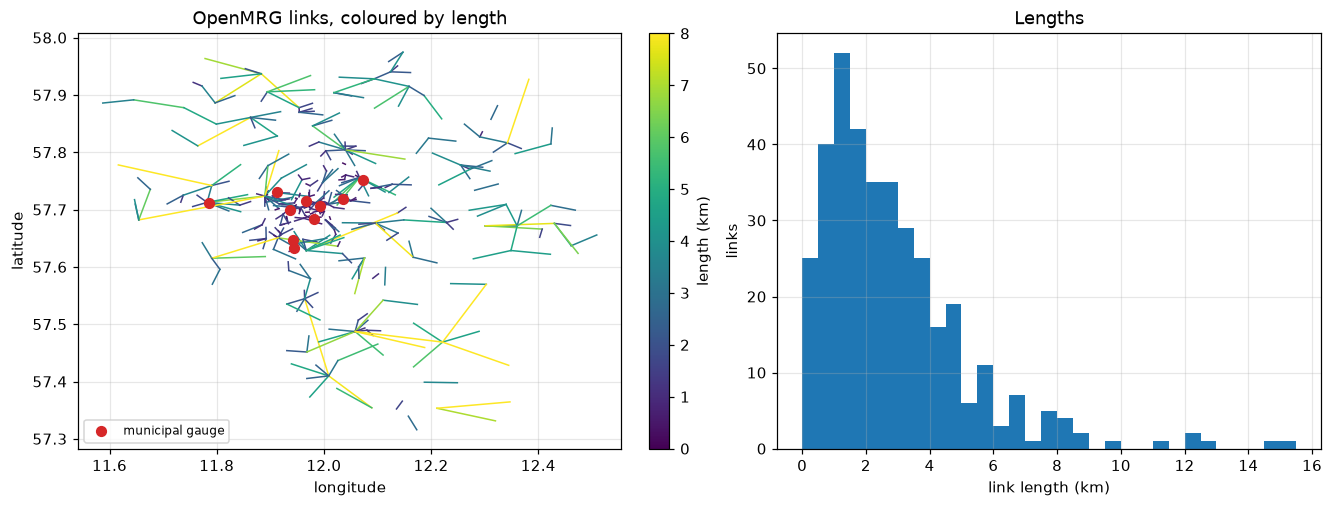

In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    data = example_data.load("openmrg", "8d")
cml_10s, radar, gauges = data["cml"], data["radar"], data["gauge_municipal"]
cml = cml_10s[["tsl", "rsl"]].resample(time="1min").mean()
cml = cml.assign_coords({c: cml_10s[c] for c in cml_10s.coords if "time" not in cml_10s[c].dims})
LABEL = example_data.DATASETS["openmrg"].accumulation_label        # time-stamp convention

L = pd.Series(cml.length_km.values, index=cml.cml_id.values, name="length_km")
f = cml.frequency_ghz.isel(sublink_id=0).values
print(f"{cml.sizes['cml_id']} links x {cml.sizes['sublink_id']} sublinks, "
      f"{str(cml.time.values[0])[:10]} to {str(cml.time.values[-1])[:10]}; "
      f"length {L.min():.2f}-{L.max():.1f} km (median {L.median():.1f}); "
      f"frequency {f.min():.0f}-{f.max():.0f} GHz; {gauges.sizes['id']} municipal gauges")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(0, 8)
for j in range(cml.sizes["cml_id"]):
    c = cml.isel(cml_id=j)
    axes[0].plot([c.site_0_lon, c.site_1_lon], [c.site_0_lat, c.site_1_lat],
                 color=cmap(norm(L.iloc[j])), lw=1)
axes[0].scatter(gauges.lon, gauges.lat, color="C3", s=40, zorder=5, label="municipal gauge")
axes[0].set(xlabel="longitude", ylabel="latitude", title="OpenMRG links, coloured by length")
axes[0].legend(loc="lower left", fontsize=8)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes[0], label="length (km)")
axes[1].hist(L, bins=np.arange(0, L.max() + 0.5, 0.5), color="C0")
axes[1].set(xlabel="link length (km)", ylabel="links", title="Lengths")
plt.show()

## 2. The chain: two retrieval arms

`core.opensense.retrieval.retrieve_dataset`: total loss, rolling-standard-deviation
wet/dry (independent of the radar, so the radar stays a fair reference), a rolling-median
dry baseline, then the power law. The two arms differ only in the wet-antenna step:

* **linear law**: no correction, $R = (A / aL)^{1/b}$ - the proposal's first arm;
* **Pastorek 2021**: the rain-dependent literature model, with the parameters of the
  OpenSense intercomparison ($A_{max} = 6$ dB, $\zeta = 0.7$, $d = 0.15$; Tutorial 2).

The chain sets links shorter than 0.5 km to missing (their rain signal is below the
quantization), so the shortest bin below starts at 0.5 km. The two sublinks of a link
share its path and are averaged.

In [3]:
cfg_linear = retrieval.RetrievalConfig.for_interval(60, waa_model="none")
cfg_pastorek = cfg_linear.with_(waa_model="pastorek2021", waa_pastorek_a_max_db=6.0,
                                waa_pastorek_zeta=0.7, waa_pastorek_d=0.15)
out = {}
for name, cfg in [("linear law", cfg_linear), ("Pastorek 2021", cfg_pastorek)]:
    out[name] = retrieval.retrieve_dataset(cml, cfg)
R = {name: retrieval.combine_sublinks(o).R.transpose("time", "cml_id") for name, o in out.items()}
pd.DataFrame({name: {"links with a retrieval": int(np.isfinite(r).any("time").sum()),
                     "mean rain over links (mm/h)": float(r.mean())} for name, r in R.items()})

,linear law,Pastorek 2021
links with a retrieval,329.000,329.000
mean rain over links (mm/h),0.487,0.191


## 3. References along each link

* **Radar along the path**: `evaluation.radar_along_links` (poligrain's `GridAtLines`),
  the radar averaged over each link's path weighted by intersection length - a path
  average, like the link itself.
* **Nearest gauge**: `evaluation.closest_gauges` keeps the municipal gauge within 2 km
  of the path, if any; links without one have no gauge reference.

In [4]:
radar_path = ev.radar_along_links(radar.R, cml)                     # (time, cml_id), mm/h, 5 min
closest = ev.closest_gauges(cml, gauges, max_distance_m=2000)
gauge_at = ev.gauge_series_at_links(gauges.R, closest)              # (time, cml_id), mm/h, 1 min
has_gauge = np.isfinite(gauge_at).any("time").values
print(f"radar along {radar_path.sizes['cml_id']} links; a gauge within 2 km for "
      f"{has_gauge.sum()} links (median distance "
      f"{np.median(gauge_at.gauge_distance_m.values[has_gauge]):.0f} m)")

radar along 364 links; a gauge within 2 km for 149 links (median distance 935 m)


## 4. Storm events, split by event

`pe.radar_events` cuts the radar to the network's box, sums it to hours and runs
`core.events.detect_events`. Events alternate between training and test, so both halves
span the eight days. Every score below uses the **test** events only (each padded one
hour before and three after, so drying tails count); a method may fit on the training
events.

In [5]:
events = pe.split_events(pe.radar_events(radar.R, cml, label=LABEL))
events[["event_id", "start", "end", "duration_h", "total_mm", "peak_hourly_mm", "split"]]

,event_id,start,end,duration_h,total_mm,peak_hourly_mm,split
0,20150723T00,2015-07-23 00:00:00,2015-07-23 03:00:00,3,1.56,0.82,train
1,20150725T05,2015-07-25 05:00:00,2015-07-25 15:00:00,10,12.71,3.15,test
2,20150725T21,2015-07-25 21:00:00,2015-07-26 08:00:00,11,9.19,2.04,train
3,20150727T08,2015-07-27 08:00:00,2015-07-27 12:00:00,4,0.81,0.32,test
4,20150728T03,2015-07-28 03:00:00,2015-07-28 19:00:00,16,7.11,1.30,train
5,20150729T00,2015-07-29 00:00:00,2015-07-29 11:00:00,11,9.49,1.59,test
6,20150729T22,2015-07-29 22:00:00,2015-07-30 00:00:00,2,0.56,0.33,train


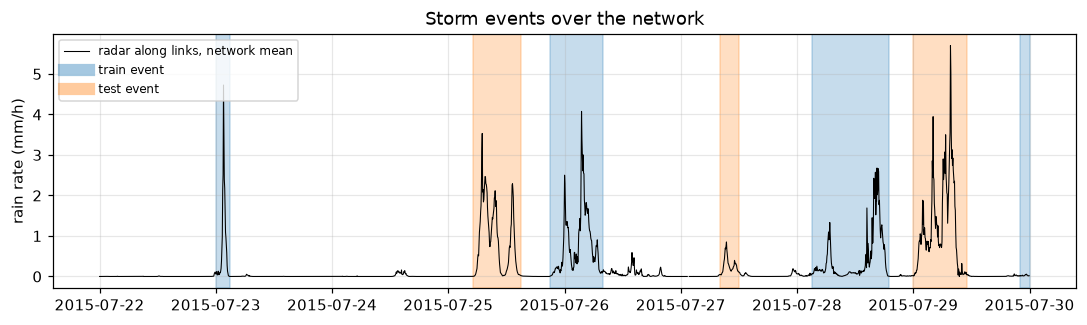

In [6]:
fig, ax = plt.subplots(figsize=(12, 3))
net_mean = radar_path.mean("cml_id")
ax.plot(net_mean.time, net_mean, color="k", lw=0.7, label="radar along links, network mean")
for _, e in events.iterrows():
    ax.axvspan(e.start, e.end, color="C1" if e.split == "test" else "C0", alpha=0.25)
ax.plot([], [], color="C0", alpha=0.4, lw=8, label="train event")
ax.plot([], [], color="C1", alpha=0.4, lw=8, label="test event")
ax.set(ylabel="rain rate (mm/h)", title="Storm events over the network")
ax.legend(fontsize=8, loc="upper left")
plt.show()

## 5. The baseline, scored by link length

Everything is averaged to 15-minute rain rates (`evaluation.aggregate`, with the
dataset's time-stamp convention) and scored on the test events with
`ps.scores_by_length`: normalized bias $\sum(\hat R - R_{ref}) / \sum R_{ref}$ and
normalized RMSE (RMSE over the mean reference), against the radar along the path and
against the nearest gauge, by link-length bin. A positive bias on short links is the
signature of a non-rain term that does not scale with length; the path law shows on
long links.

In [7]:
agg = lambda da: ev.aggregate(da, "15min", label=LABEL)
refs = {"radar": agg(radar_path), "gauge": agg(gauge_at)}
scores = {}
for name, r in R.items():
    est = agg(r)
    test = pe.event_mask(est.time.values, events, "test")
    scores[name] = ps.scores_by_length(est, refs, L.values, time_mask=test)
baseline = pd.concat(scores, names=["arm"])
baseline

links  radar                       gauge                 \
                          n  nbias  nrmse      r      n  nbias   nrmse      r   
arm           length                                                            
linear law    0-1 km     65  1.644  6.892  0.575   5772  2.863  10.572  0.617   
              1-2 km     94  0.547  3.955  0.516  13912  1.291   5.723  0.614   
              2-4 km    124  0.063  2.642  0.591  17424  0.314   2.592  0.738   
              4-8 km     68 -0.060  2.134  0.648   9620  0.050   2.170  0.738   
              8-20 km    13  0.162  2.463  0.507   1924  0.643   2.880  0.624   
              all       364  0.383  3.803  0.531  48652  1.147   5.870  0.573   
Pastorek 2021 0-1 km     65 -0.384  2.617  0.514   5772 -0.074   3.633  0.553   
              1-2 km     94 -0.448  2.463  0.462  13912 -0.197   3.216  0.533   
              2-4 km    124 -0.460  2.126  0.551  17424 -0.331   2.193  0.712   
              4-8 km     68 -0.498  1.922  0.621   9620 -0.394   2.128  0.732   
              8-20 km    13 -0.575  1.903  0.526   1924 -0.451   2.144  0.660   
              all       364 -0.458  2.263  0.522  48652 -0.246   2.837  0.586   

                              
                           n  
arm           length          
linear law    0-1 km    4292  
              1-2 km    6512  
              2-4 km    4736  
              4-8 km    2072  
              8-20 km    592  
              all      18204  
Pastorek 2021 0-1 km    4292  
              1-2 km    6512  
              2-4 km    4736  
              4-8 km    2072  
              8-20 km    592  
              all      18204

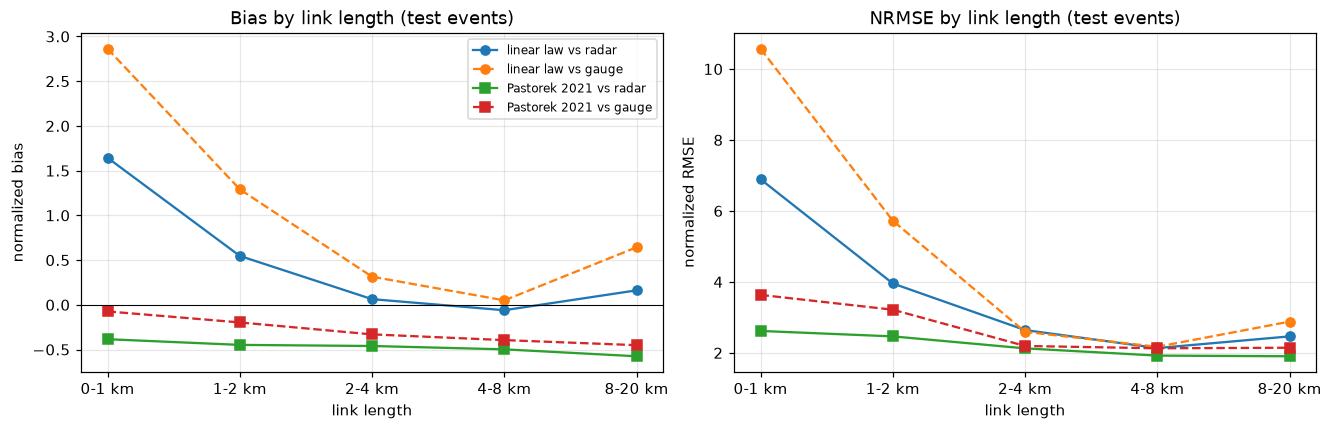

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
bins = [b for b in scores["linear law"].index if b != "all"]
for (name, s), m in zip(scores.items(), ("o", "s")):
    for ref, ls in (("radar", "-"), ("gauge", "--")):
        axes[0].plot(bins, s.loc[bins, (ref, "nbias")], ls, marker=m, label=f"{name} vs {ref}")
        axes[1].plot(bins, s.loc[bins, (ref, "nrmse")], ls, marker=m, label=f"{name} vs {ref}")
axes[0].axhline(0, color="k", lw=0.7)
axes[0].set(xlabel="link length", ylabel="normalized bias", title="Bias by link length (test events)")
axes[1].set(xlabel="link length", ylabel="normalized RMSE", title="NRMSE by link length (test events)")
axes[0].legend(fontsize=8)
plt.show()

## 6. Inputs for a method

What a learned path law or non-rain term works from, on one time axis (1 min) and one
link axis: the excess attenuation over the baseline (`A_obs`, averaged over the two
sublinks), the radar along the path held over its 5-minute step, the nearest gauge, and
per-link length, frequency and polarization. Fit on `split == "train"` events only.

In [9]:
radar_1min = radar_path.reindex(time=cml.time.values, method="ffill")
inputs = xr.Dataset({
    "A_obs": out["linear law"].A_obs.mean("sublink_id").transpose("time", "cml_id"),
    "R_radar": radar_1min.transpose("time", "cml_id"),
    "R_gauge": gauge_at.reindex(time=cml.time.values).transpose("time", "cml_id"),
}, coords={"length_km": ("cml_id", L.values), "frequency_ghz": ("cml_id", f),
           "polarization": ("cml_id", cml.polarization.isel(sublink_id=0).values)})
inputs["train"] = ("time", pe.event_mask(cml.time.values, events, "train"))
inputs["test"] = ("time", pe.event_mask(cml.time.values, events, "test"))
inputs

<xarray.Dataset> Size: 101MB
Dimensions:           (cml_id: 364, time: 11520)
Coordinates: (12/18)
    site_0_lat        (cml_id) float64 3kB 57.7 57.73 57.69 ... 57.66 57.71
    site_0_lon        (cml_id) float64 3kB 12.0 11.98 11.97 ... 12.03 12.01
    site_1_lat        (cml_id) float64 3kB 57.7 57.72 57.69 ... 57.63 57.71
    site_1_lon        (cml_id) float64 3kB 11.99 11.97 11.98 ... 11.97 11.98
    length            (cml_id) float64 3kB 691.4 614.6 ... 4.806e+03 1.412e+03
    length_km         (cml_id) float64 3kB 0.6914 0.6146 0.3237 ... 4.806 1.412
    ...                ...
  * cml_id            (cml_id) int64 3kB 10001 10002 10003 ... 10362 10363 10364
  * time              (time) datetime64[ns] 92kB 2015-07-22 ... 2015-07-29T23...
    gauge_id          (cml_id) object 3kB 'Drakeg' 'Lbom' ... 'Askim' 'Drakeg'
    gauge_distance_m  (cml_id) float64 3kB 287.0 962.2 ... 1.478e+03 530.0
    frequency_ghz     (cml_id) float64 3kB 28.21 38.53 38.53 ... 28.18 28.25
    polarization      (cml_id) <U10 15kB 'vertical' 'vertical' ... 'vertical'
Data variables:
    A_obs             (time, cml_id) float64 34MB 0.1 0.075 0.2125 ... 0.0 0.0
    R_radar           (time, cml_id) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    R_gauge           (time, cml_id) float64 34MB 0.0 0.0 0.0 ... nan 0.0 0.0
    train             (time) bool 12kB False False False ... True True True
    test              (time) bool 12kB False False False ... False False False

## 7. Your method goes here

Produce a `(time, cml_id)` rain rate in mm/h at 1 minute - for example by inverting your
$\hat f(R, L)$ from notebook 01, with or without a learned non-rain term from notebook
03, on `inputs.A_obs` - fitting only on the training events. The cell scores it exactly
as the baseline above, so the rows can be compared bin by bin.

In [10]:
# ---- your method goes here ------------------------------------------------------
# R_method = your_retrieval(inputs.where(inputs.train))  ...applied to every time step
R_method = R["linear law"]                    # placeholder: the linear-law baseline
est = agg(R_method)
ps.scores_by_length(est, refs, L.values, time_mask=pe.event_mask(est.time.values, events, "test"))

links  radar                       gauge                      
            n  nbias  nrmse      r      n  nbias   nrmse      r      n
length                                                                
0-1 km     65  1.644  6.892  0.575   5772  2.863  10.572  0.617   4292
1-2 km     94  0.547  3.955  0.516  13912  1.291   5.723  0.614   6512
2-4 km    124  0.063  2.642  0.591  17424  0.314   2.592  0.738   4736
4-8 km     68 -0.060  2.134  0.648   9620  0.050   2.170  0.738   2072
8-20 km    13  0.162  2.463  0.507   1924  0.643   2.880  0.624    592
all       364  0.383  3.803  0.531  48652  1.147   5.870  0.573  18204

## References

* Andersson, J. C. M., et al. (2022). OpenMRG: Open data from Microwave links, Radar, and
  Gauges for rainfall quantification in Gothenburg, Sweden. *Earth Syst. Sci. Data*, 14,
  5411-5426. [doi:10.5194/essd-14-5411-2022](https://doi.org/10.5194/essd-14-5411-2022)
* Pastorek, J., Fencl, M., Rieckermann, J., and Bares, V. (2021). Precipitation estimates
  from commercial microwave links: Practical approaches to wet-antenna correction.
  *IEEE Trans. Geosci. Remote Sens.*, 60, 1-9.
  [doi:10.1109/TGRS.2021.3110004](https://doi.org/10.1109/TGRS.2021.3110004)
* Schleiss, M., and Berne, A. (2010). Identification of dry and rainy periods using
  telecommunication microwave links. *IEEE Geosci. Remote Sens. Lett.*, 7(3), 611-615.